# Семинар 2. Исследовательский анализ и объяснение данных (Python)

Продолжаем работать с данными сталелитейного предприятия, подготовленными
на первом семинаре. Пройдём путь от описательной статистики до выделения режимов работы:

1. исследуем распределения и взаимосвязи признаков;
2. добавим календарные признаки и уровень загрузки;
3. снизим размерность методом главных компонент (PCA);
4. выделим режимы алгоритмом k-средних;
5. проверим статистическую гипотезу и найдём периодичности с помощью FFT.

Все примеры написаны только на Python. Данные лежат в папке `data_seminar` рядом с блокнотом.

## Импорт библиотек

`pandas` и `numpy` отвечают за таблицы и вычисления, `matplotlib` — за графики,
`scipy` — за статистические тесты, а `scikit-learn` — за масштабирование, PCA и кластеризацию.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

DATA = Path("data_seminar")
OUT = Path("output")
OUT.mkdir(exist_ok=True)

plt.rcParams.update({"figure.figsize": (10, 4.5), "axes.grid": True})
pd.set_option("display.max_columns", 20)

NUMERIC = [
    "Usage_kWh",
    "Lagging_Current_Reactive_Power_kVarh",
    "Leading_Current_Reactive_Power_kVarh",
    "CO2_tCO2_",
    "Lagging_Current_Power_Factor",
    "Leading_Current_Power_Factor",
    "Temperature_C",
    "Humidity_Pct",
]

SHORT_NAMES = [
    "Потребление", "Реакт. мощность (-)", "Реакт. мощность (+)", "CO₂",
    "Коэф. мощности (-)", "Коэф. мощности (+)", "Температура", "Влажность",
]

## Загрузка и проверка данных

Набор содержит 35 040 измерений с шагом 15 минут — по 96 измерений в сутки в течение года.
Сначала проверим размер, столбцы, пропуски и дубликаты.

In [3]:
df = pd.read_csv(DATA / "Сталелитейные_данные.csv")

print("Размерность:", df.shape)
print("Пропусков:", int(df.isna().sum().sum()))
print("Полных дубликатов:", int(df.duplicated().sum()))
df.head(3)

Размерность: (35040, 10)
Пропусков: 0
Полных дубликатов: 0


,date,Usage_kWh,Lagging_Current_Reactive_Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2_tCO2_,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,DateTime,Temperature_C,Humidity_Pct
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,2018-01-01T00:15:00.0,-12.3,91.2
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,2018-01-01T00:30:00.0,-9.8,82.8
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2018-01-01T00:45:00.0,-9.7,86.0


## Время и порядок наблюдений

Восстановим временную метку из исходного столбца `date`. Как было замечено в первом семинаре,
строка с полуночью записана в конце каждого суточного блока, поэтому перед анализом временного
ряда данные нужно отсортировать.

In [5]:
df["DateTime"] = pd.to_datetime(df["date"], format="%d/%m/%Y %H:%M")
print("Диапазон:", df["DateTime"].min(), "—", df["DateTime"].max())
print("Время изначально упорядочено:", df["DateTime"].is_monotonic_increasing)

df = df.sort_values("DateTime").reset_index(drop=True)
step = df["DateTime"].diff().dropna()
print("После сортировки; уникальный шаг:", step.unique())

Диапазон: 2018-01-01 00:00:00 — 2018-12-31 23:45:00
Время изначально упорядочено: True
После сортировки; уникальный шаг: <TimedeltaArray>
['0 days 00:15:00']
Length: 1, dtype: timedelta64[us]


## Описательная статистика

`describe()` показывает число наблюдений, среднее, стандартное отклонение, квартили и границы.
Транспонирование `.T` размещает признаки по строкам — так длинную таблицу удобнее читать.

In [6]:
summary = df[NUMERIC].describe().T
summary.round(3)

,count,mean,std,min,25%,50%,75%,max
Usage_kWh,35040.0,27.387,33.444,0.0,3.20,4.57,51.238,157.18
Lagging_Current_Reactive_Power_kVarh,35040.0,13.035,16.306,0.0,2.30,5.00,22.640,96.91
Leading_Current_Reactive_Power_kVarh,35040.0,3.871,7.424,0.0,0.00,0.00,2.090,27.76
CO2_tCO2_,35040.0,0.012,0.016,0.0,0.00,0.00,0.020,0.07
Lagging_Current_Power_Factor,35040.0,80.578,18.921,0.0,63.32,87.96,99.022,100.00
Leading_Current_Power_Factor,35040.0,84.368,30.457,0.0,99.70,100.00,100.000,100.00
Temperature_C,35040.0,2.320,13.379,-28.9,-9.40,2.10,13.700,37.40
Humidity_Pct,35040.0,69.990,11.656,32.8,61.60,70.25,78.500,98.00


## Корреляционная матрица

Коэффициент корреляции Пирсона принимает значения от −1 до 1. Большой модуль означает сильную
линейную связь, но сам по себе не доказывает причинность.

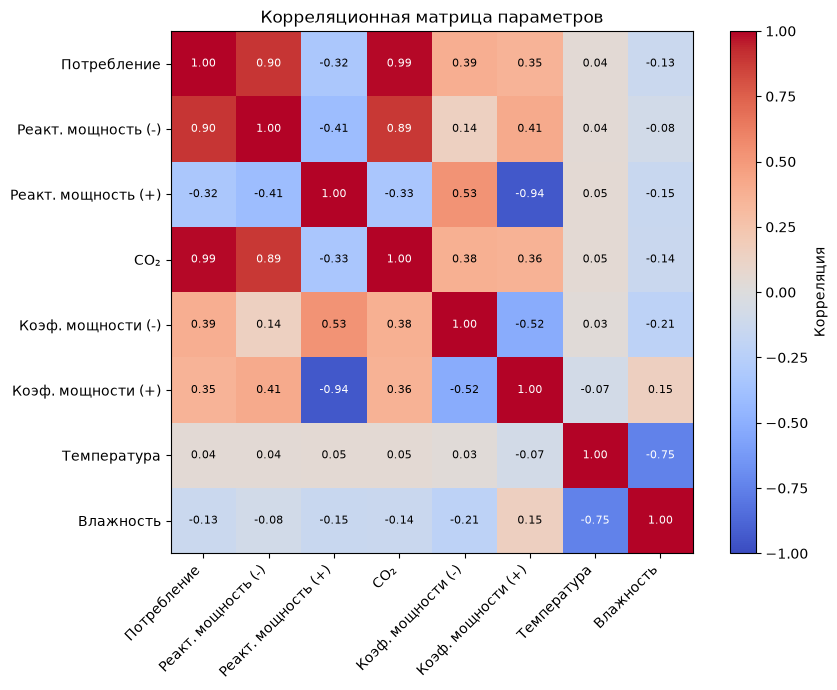

In [7]:
corr = df[NUMERIC].corr()

fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(SHORT_NAMES)), SHORT_NAMES, rotation=45, ha="right")
ax.set_yticks(range(len(SHORT_NAMES)), SHORT_NAMES)
for i in range(len(NUMERIC)):
    for j in range(len(NUMERIC)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(corr.iloc[i, j]) > 0.55 else "black")
fig.colorbar(image, ax=ax, label="Корреляция")
ax.set_title("Корреляционная матрица параметров")
ax.grid(False)
plt.tight_layout()
plt.show()

### Самые сильные связи

Уберём диагональ и повторяющиеся пары, затем отсортируем связи по модулю.

In [8]:
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .rename("correlation")
        .reset_index()
)
pairs.columns = ["feature_1", "feature_2", "correlation"]
pairs["abs_correlation"] = pairs["correlation"].abs()
pairs.nlargest(10, "abs_correlation").round(3)

,feature_1,feature_2,correlation,abs_correlation
3,Usage_kWh,CO2_tCO2_,0.988,0.988
21,Leading_Current_Reactive_Power_kVarh,Leading_Current_Power_Factor,-0.944,0.944
1,Usage_kWh,Lagging_Current_Reactive_Power_kVarh,0.896,0.896
11,Lagging_Current_Reactive_Power_kVarh,CO2_tCO2_,0.887,0.887
55,Temperature_C,Humidity_Pct,-0.747,0.747
20,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,0.527,0.527
37,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,-0.520,0.520
13,Lagging_Current_Reactive_Power_kVarh,Leading_Current_Power_Factor,0.408,0.408
10,Lagging_Current_Reactive_Power_kVarh,Leading_Current_Reactive_Power_kVarh,-0.405,0.405
4,Usage_kWh,Lagging_Current_Power_Factor,0.386,0.386


## Диаграмма рассеяния

Сравним потребление и выбросы CO₂, а температуру закодируем цветом.

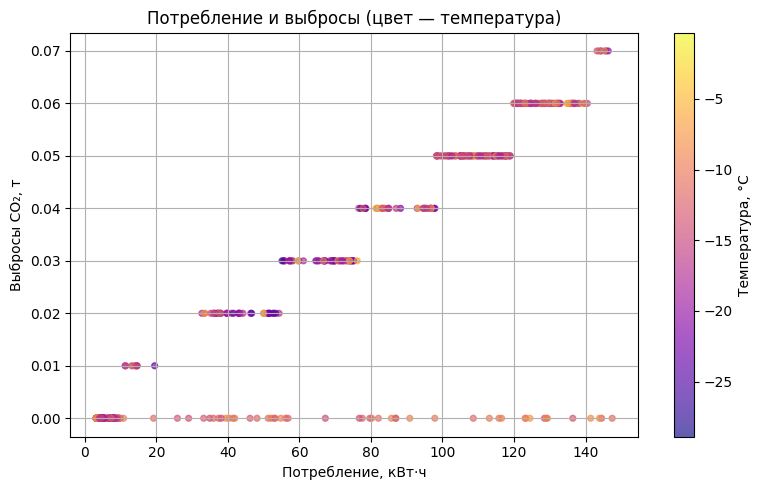

In [7]:
sample = df.iloc[:1000]
fig, ax = plt.subplots(figsize=(8, 5))
points = ax.scatter(sample["Usage_kWh"], sample["CO2_tCO2_"],
                    c=sample["Temperature_C"], cmap="plasma", alpha=0.65, s=18)
fig.colorbar(points, ax=ax, label="Температура, °C")
ax.set(xlabel="Потребление, кВт·ч", ylabel="Выбросы CO₂, т",
       title="Потребление и выбросы (цвет — температура)")
plt.tight_layout()
plt.show()

## Календарные признаки и анализ по сезонам

Месяц, сезон, час и день недели не измерены датчиком, но извлекаются из времени и помогают
объяснять режимы предприятия. Такие производные переменные называют **признаками**.

In [8]:
season_by_month = {
    1: "Зима", 2: "Зима", 3: "Весна", 4: "Весна", 5: "Весна",
    6: "Лето", 7: "Лето", 8: "Лето",
    9: "Осень", 10: "Осень", 11: "Осень", 12: "Зима",
}
season_order = ["Зима", "Весна", "Лето", "Осень"]

df["Season"] = pd.Categorical(
    df["DateTime"].dt.month.map(season_by_month), categories=season_order, ordered=True
)
season_stats = (
    df.groupby("Season", observed=True)
      .agg(avg_usage=("Usage_kWh", "mean"),
           std_usage=("Usage_kWh", "std"),
           avg_temp=("Temperature_C", "mean"))
      .reset_index()
)
season_stats.round(2)

,Season,avg_usage,std_usage,avg_temp
0,Зима,32.08,37.13,-12.13
1,Весна,26.95,32.85,8.53
2,Лето,24.42,30.74,16.75
3,Осень,26.19,32.32,-4.25


### Распределение потребления по сезонам

Boxplot показывает медиану, квартили, типичный разброс и выбросы.

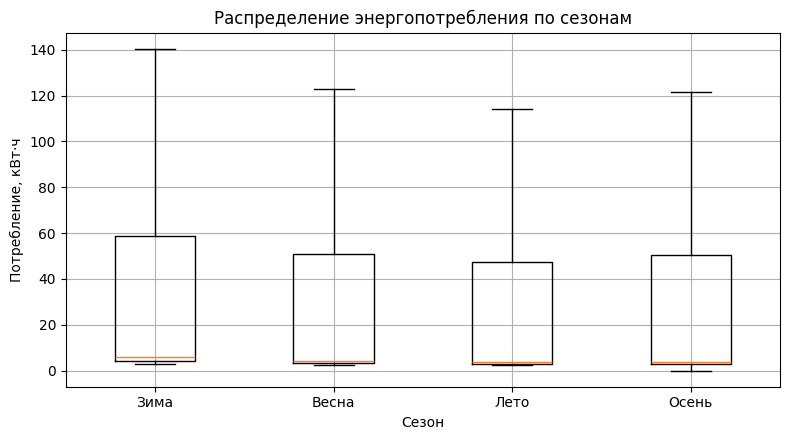

In [9]:
season_values = [df.loc[df["Season"] == season, "Usage_kWh"] for season in season_order]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.boxplot(season_values, tick_labels=season_order, showfliers=False)
ax.set(xlabel="Сезон", ylabel="Потребление, кВт·ч",
       title="Распределение энергопотребления по сезонам")
plt.tight_layout()
plt.show()

## Суточный профиль

Сгруппируем измерения по часу суток и покажем среднее вместе с полосой ± одно стандартное отклонение.

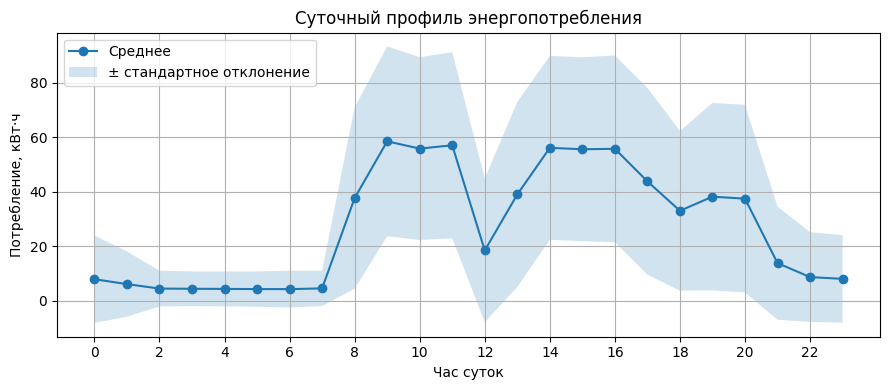

In [10]:
df["Hour"] = df["DateTime"].dt.hour
hourly = df.groupby("Hour")["Usage_kWh"].agg(["mean", "std"])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hourly.index, hourly["mean"], marker="o", label="Среднее")
ax.fill_between(hourly.index, hourly["mean"] - hourly["std"],
                hourly["mean"] + hourly["std"], alpha=0.2, label="± стандартное отклонение")
ax.set(xlabel="Час суток", ylabel="Потребление, кВт·ч",
       title="Суточный профиль энергопотребления", xticks=range(0, 24, 2))
ax.legend()
plt.tight_layout()
plt.show()

## Признак уровня загрузки

Разделим наблюдения по 33-му и 67-му процентилям. Получатся три близкие по численности группы;
границы определяются данными, а не выбираются произвольно.

In [11]:
q33, q67 = df["Usage_kWh"].quantile([0.33, 0.67])
df["LoadLevel"] = pd.cut(
    df["Usage_kWh"], bins=[-np.inf, q33, q67, np.inf],
    labels=["Низкая", "Средняя", "Высокая"], include_lowest=True,
)
print(f"Границы: {q33:.2f} и {q67:.2f} кВт·ч")
df["LoadLevel"].value_counts(sort=False).rename("count").to_frame()

Границы: 3.49 и 38.16 кВт·ч


,count
LoadLevel,
Низкая,11634
Средняя,11851
Высокая,11555


## PCA: снижение размерности

**PCA (метод главных компонент)** — способ уменьшить число признаков, сохранив основную информацию в данных.

Признаки измерены в разных единицах, поэтому сначала стандартизируем их: среднее станет равным
нулю, стандартное отклонение — единице. Затем PCA найдёт два направления максимального разброса.


осемь исходных параметров были преобразованы в две главные компоненты, которые объясняют **71,7% общего разброса данных**. Это позволяет визуализировать многомерные наблюдения на плоскости и увидеть структуру режимов работы предприятия.

Объяснённая дисперсия по компонентам: [0.425 0.292]
Суммарно: 71.7%


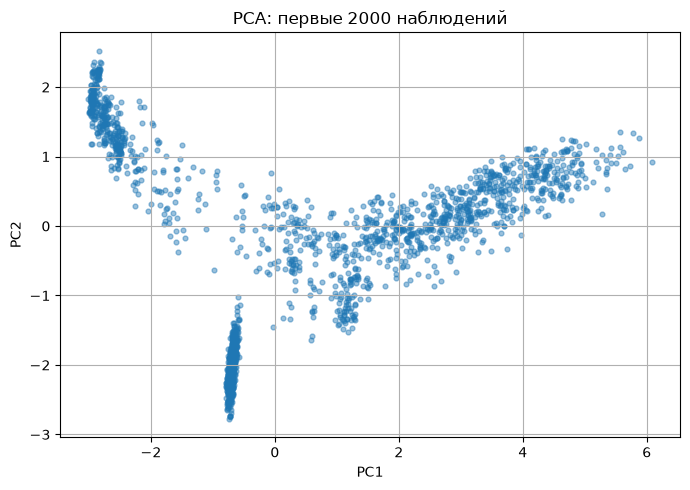

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[NUMERIC])

pca = PCA(n_components=2)
projection = pca.fit_transform(X_scaled)

print("Объяснённая дисперсия по компонентам:", np.round(pca.explained_variance_ratio_, 3))
print("Суммарно:", f"{pca.explained_variance_ratio_.sum():.1%}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(projection[:2000, 0], projection[:2000, 1], s=12, alpha=0.45)
ax.set(xlabel="PC1", ylabel="PC2", title="PCA: первые 2000 наблюдений")
plt.tight_layout()
plt.show()

## Кластеризация режимов работы

Алгоритм k-средних разбивает наблюдения на три компактные группы. `random_state` фиксирует
случайную инициализацию, а `n_init=20` выбирает лучший результат из двадцати запусков.
Номера кластеров условны и не имеют естественного порядка.

Размеры кластеров:
Cluster
0    12864
1    14499
2     7677
Name: count, dtype: int64


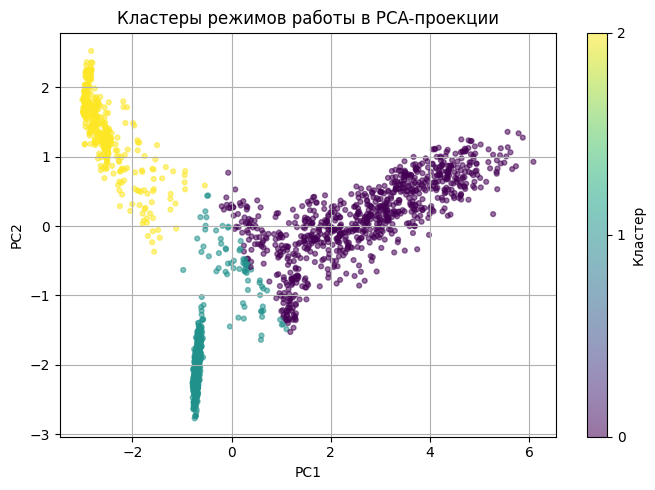

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("Размеры кластеров:")
print(df["Cluster"].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(projection[:2000, 0], projection[:2000, 1],
                     c=df.loc[:1999, "Cluster"], cmap="viridis", s=12, alpha=0.55)
ax.set(xlabel="PC1", ylabel="PC2", title="Кластеры режимов работы в PCA-проекции")
fig.colorbar(scatter, ax=ax, label="Кластер", ticks=range(3))
plt.tight_layout()
plt.show()

### Интерпретация кластеров

Средние исходных параметров дают содержательное описание найденных групп.

In [14]:
cluster_stats = (
    df.groupby("Cluster")
      .agg(size=("Cluster", "size"),
           avg_usage=("Usage_kWh", "mean"),
           avg_temp=("Temperature_C", "mean"),
           avg_humidity=("Humidity_Pct", "mean"),
           avg_power_factor=("Lagging_Current_Power_Factor", "mean"))
)
cluster_stats.round(2)

,size,avg_usage,avg_temp,avg_humidity,avg_power_factor
Cluster,,,,,
0,12864,66.10,4.11,67.07,90.56
1,14499,4.77,-0.45,74.53,61.57
2,7677,5.23,4.56,66.31,99.75


## Проверка гипотезы: будни и выходные

Проверим нулевую гипотезу о равенстве среднего потребления. Используем t-критерий Уэлча,
который не требует равенства дисперсий. Малое p-value говорит против равенства средних,
но из-за временной зависимости наблюдений результат следует трактовать осторожно.

In [15]:
df["DayOfWeek"] = df["DateTime"].dt.dayofweek  # понедельник = 0
df["IsWeekend"] = df["DayOfWeek"] >= 5

weekdays = df.loc[~df["IsWeekend"], "Usage_kWh"]
weekends = df.loc[df["IsWeekend"], "Usage_kWh"]
test = ttest_ind(weekdays, weekends, equal_var=False)

print(f"Среднее в будни:    {weekdays.mean():.2f} кВт·ч")
print(f"Среднее в выходные: {weekends.mean():.2f} кВт·ч")
print(f"t = {test.statistic:.2f}; p-value = {test.pvalue:.3e}")

Среднее в будни:    33.62 кВт·ч
Среднее в выходные: 11.73 кВт·ч
t = 72.77; p-value = 0.000e+00


## Коэффициент мощности

Низкий коэффициент мощности указывает на большую долю реактивной энергии и менее эффективное использование сети.

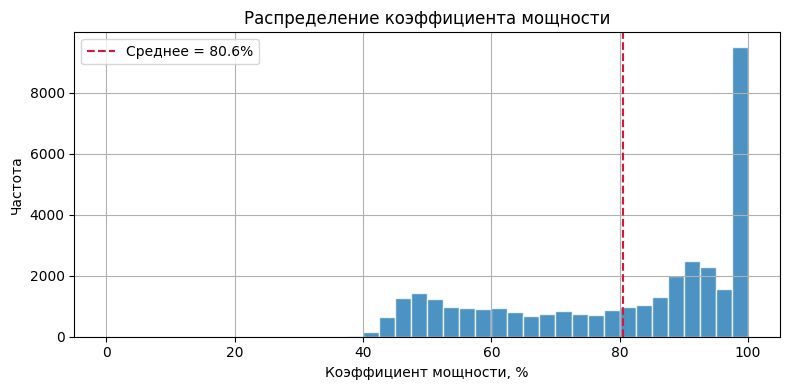

In [16]:
power_factor = df["Lagging_Current_Power_Factor"]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(power_factor, bins=40, edgecolor="white", alpha=0.8)
ax.axvline(power_factor.mean(), color="crimson", linestyle="--",
           label=f"Среднее = {power_factor.mean():.1f}%")
ax.set(xlabel="Коэффициент мощности, %", ylabel="Частота",
       title="Распределение коэффициента мощности")
ax.legend()
plt.tight_layout()
plt.show()

## Спектральный анализ временного ряда

Измерения идут каждые 15 минут, то есть 96 раз в сутки. Возьмём первые 4096 упорядоченных
отсчётов, вычтем среднее и применим действительное FFT. Ось частот выразим в циклах в сутки.
Пик около 1 соответствует суточной периодичности, около 1/7 — недельной.

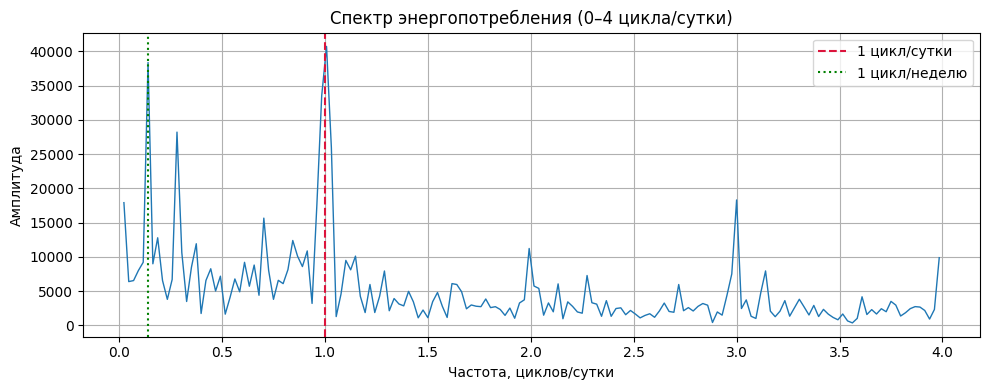

In [17]:
n = 4096
samples_per_day = 96
signal = df["Usage_kWh"].iloc[:n].to_numpy()
signal = signal - signal.mean()
spectrum = np.abs(np.fft.rfft(signal))
frequencies = np.fft.rfftfreq(n, d=1 / samples_per_day)

mask = (frequencies > 0) & (frequencies <= 4)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(frequencies[mask], spectrum[mask], linewidth=1)
ax.axvline(1, color="crimson", linestyle="--", label="1 цикл/сутки")
ax.axvline(1 / 7, color="green", linestyle=":", label="1 цикл/неделю")
ax.set(xlabel="Частота, циклов/сутки", ylabel="Амплитуда",
       title="Спектр энергопотребления (0–4 цикла/сутки)")
ax.legend()
plt.tight_layout()
plt.show()

### Доминирующие частоты

Найдём крупнейшие пики, исключив постоянную составляющую (нулевую частоту).

In [18]:
peak_indices = np.argsort(spectrum[1:])[::-1][:8] + 1
peaks = pd.DataFrame({
    "frequency_cycles_per_day": frequencies[peak_indices],
    "period_days": 1 / frequencies[peak_indices],
    "amplitude": spectrum[peak_indices],
})
peaks.round(3)

,frequency_cycles_per_day,period_days,amplitude
0,1.008,0.992,40734.219
1,0.141,7.111,38384.401
2,0.984,1.016,33541.452
3,0.281,3.556,28217.182
4,1.031,0.970,25975.966
5,3.000,0.333,18309.831
6,0.023,42.667,17914.934
7,0.961,1.041,17666.798


## Сохранение результата

Сохраним исходные и добавленные признаки. PCA-координаты также пригодятся для дальнейшей визуализации.

In [19]:
df["PC1"] = projection[:, 0]
df["PC2"] = projection[:, 1]

result_path = OUT / "Новые_данные.csv"
df.to_csv(result_path, index=False, encoding="utf-8")
print("Сохранено:", result_path)
print("Размерность:", df.shape)
print("Новые столбцы:", ["Season", "Hour", "LoadLevel", "Cluster", "DayOfWeek",
                         "IsWeekend", "PC1", "PC2"])

Сохранено: output/Новые_данные.csv
Размерность: (35040, 18)
Новые столбцы: ['Season', 'Hour', 'LoadLevel', 'Cluster', 'DayOfWeek', 'IsWeekend', 'PC1', 'PC2']


## Итоги

Мы рассчитали описательные статистики и корреляции, сравнили сезоны и часы суток, создали
календарные и категориальные признаки, визуализировали многомерные данные через PCA, нашли
режимы работы с помощью k-средних, проверили гипотезу и исследовали периодичности методом FFT.

Главное правило интерпретации: статистическая связь и красивое разделение на графике ещё не
доказывают причинность. Выводы нужно сопоставлять с устройством технологического процесса.